# Compute for Cryptobench
Take the model from https://doi.org/10.1145/3765612.3767221 and measure the pocket level metrics.



In [ ]:
from transformers import AutoTokenizer
import torch
import numpy as np
import functools
from sklearn import metrics
from torch.utils.data import DataLoader
import sys
import pickle

PATH = '/home/skrhakv/Projects/seq2pocket'
sys.path.append(f'{PATH}/src/utils')
sys.path.append(f'{PATH}/../cryptic-nn/src')
import finetuning_utils # download from https://github.com/skrhakv/cryptic-finetuning/blob/master/src/finetuning_utils.py
from finetuning_utils import FinetunedEsmModel
import eval_utils
from eval_utils import CryptoBenchClassifier
import cryptoshow_utils
import clustering_utils

MODEL_NAME = 'facebook/esm2_t36_3B_UR50D'
device = 'cuda' if torch.cuda.is_available() else 'cpu'

MODEL_PATH = f"{PATH}/data/models/cbs-model.pt"

SMOOTHING_MODEL_PATH = f"{PATH}/data/models/smoother.pt"
smoothing_model = torch.load(SMOOTHING_MODEL_PATH, weights_only=False) #, map_location=torch.device('cpu'))

ESM_EMBEDDINGS_PATH = f"{PATH}/data/embeddings/cryptobench"
COORDINATES_DIR = f"{PATH}/data/coordinates/cryptobench"
POSITIVE_DISTANCE_THRESHOLD = 15
PRECALCULATED = False
PREDICTIONS_PATH = f'{PATH}/data/predictions'
CB_PATH = f'{PATH}/data/data-extraction/cryptobench-clustered-binding-sites.csv'

PRECALCULATED_PATH = f'{PREDICTIONS_PATH}/cbs-model'
DECISION_THRESHOLD = 0.7

In [ ]:
model = torch.load(MODEL_PATH, weights_only=False)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

binding_residues, sequences = eval_utils.read_test_binding_residues(CB_PATH)

predicted_binding_sites = {}
ranks = {}
prediction_scores = {}

K = 2

DCCs_N = []
DCCs_N_plus_K = []
DCCs = []
number_of_overlapping_predictions_on_actual_pocket = []
number_of_overlapping_actual_sites_on_predicted_pocket = []
best_residue_overlaps = []

for i, protein_id in enumerate(sequences.keys()):
    pdb_id, chain_id = protein_id.split('_')
    sequence = sequences[protein_id]
    embeddings_path = f'{ESM_EMBEDDINGS_PATH}/{pdb_id}{chain_id}.npy'
    coordinates_path = f'{COORDINATES_DIR}/{pdb_id}{chain_id}.npy'
    actual_binding_sites = [np.array([int(i.split('_')[1]) for i in pocket]) for pocket in binding_residues[protein_id]]
    
    print(f'Processing {protein_id} ({i+1}/{len(sequences)})...')
    if not PRECALCULATED:
        # finetuned prediction
        probabilities = eval_utils.compute_prediction(
            sequence,
            f'/tmp/skrhakv',
            model,
            tokenizer
        )
    else:
        # load precalculated prediction
        probabilities = np.load(f'{PRECALCULATED_PATH}/{protein_id.replace("_","")}.npy')
    
    prediction_scores[protein_id] = probabilities

    coordinates = np.load(coordinates_path)
    distance_matrix = eval_utils.compute_distance_matrix(coordinates)

    predictions = (probabilities > DECISION_THRESHOLD).astype(float)
    predictions_copy = predictions.copy()

    assert distance_matrix.shape[0] == distance_matrix.shape[1]
    assert distance_matrix.shape[0] == predictions_copy.shape[0]
    
    X_test = np.load(embeddings_path)
    if X_test.shape[0] != distance_matrix.shape[0]:
        print(f"Skipping {protein_id} due to embedding/coordinate size mismatch.")
        continue
    # assert X_test.shape[0] == distance_matrix.shape[0]

    # loop over the residues that are not binding and are potential candidates for smoothing
    additional_residues = []
    for residue_idx in np.where(predictions == 0.0)[0]:

        # get the embedding of the residue
        current_residue_embedding = X_test[residue_idx]

        # get the close binding residues
        close_residues_indices = np.where(distance_matrix[residue_idx] < POSITIVE_DISTANCE_THRESHOLD)[0]
        close_binding_residues_indices = np.intersect1d(close_residues_indices, np.where(predictions == 1.0)[0])
        # create embedding 
        if len(close_binding_residues_indices) == 0:
            # no close binding residues - skip this residue
            continue
        elif len(close_binding_residues_indices) == 1:
            surrounding_embedding = X_test[close_binding_residues_indices].reshape(-1)
        else:
            # get the mean of the close binding residues
            surrounding_embedding = np.mean(X_test[close_binding_residues_indices], axis=0).reshape(-1)

        concatenated_embedding = torch.tensor(np.concatenate((current_residue_embedding, surrounding_embedding), axis=0), dtype=torch.float32).to(device)
        
        # get the prediction
        test_logits = smoothing_model(concatenated_embedding).squeeze()
        result = (torch.sigmoid(test_logits)>eval_utils.SMOOTHING_DECISION_THRESHOLD).float()
        if result == 1:
            # set the residue as binding
            # print(f"Smoothing changed residue {residue_idx} in protein {protein_id} to binding")
            additional_residues.append(residue_idx)
            predictions_copy[residue_idx] = 1

    indices_above_threshold = np.where(predictions_copy > DECISION_THRESHOLD)[0] # this gets residues that are equal to 1
    # no predicted residues - continue
    if len(indices_above_threshold) == 0:
        print(f"Skipping {protein_id} due to no predicted binding residues.")
        continue

    # run atom-level clustering and return residue-level pockets
    clusters, cluster_residues, cluster_scores, atom_coords, residue_coords = clustering_utils.execute_atom_clustering(
        pdb_id,
        chain_id,
        indices_above_threshold,
        probabilities[indices_above_threshold],
        eps=9
    )

    # none of the residues are on the surface
    if cluster_residues is None:
        print(f"Skipping {protein_id} due to no surface binding residues.")
        continue

    cluster_residues = cryptoshow_utils.map_auth_to_mmcif_numbering_array(
        pdb_id,
        chain_id,
        cluster_residues.values(),
        binding_residues_are_integers=True,
        numbers_only=True
    )[0]

    cluster_order = np.argsort(cluster_scores)[::-1]  # descending order
    N = len(actual_binding_sites)

    selected_clusters_N = cluster_order[:N]
    selected_clusters_N_plus_K = cluster_order[:N+K]

    predicted_centers = {}
    for cluster_label, atom_indices in clusters.items():
        cluster_coords = np.array([atom_coords[atom_id] for atom_id in atom_indices])
        cluster_center = np.mean(cluster_coords, axis=0).get_array()
        predicted_centers[cluster_label] = cluster_center
    
    actual_centers = []

    for pocket in actual_binding_sites:
        pocket_coords = coordinates[pocket]
        pocket_center = np.mean(pocket_coords, axis=0)
        actual_centers.append(pocket_center)
    
    for i, center in enumerate(actual_centers):
        DCC_N = float('inf')
        for j in selected_clusters_N:
            predicted_center = predicted_centers[j]
            distance = np.linalg.norm(center - predicted_center)
            if distance < DCC_N:
                DCC_N = distance
        
        if DCC_N != float('inf'):
            DCCs_N.append(DCC_N)

        DCC_N_plus_K = float('inf')
        for j in selected_clusters_N_plus_K:
            predicted_center = predicted_centers[j]
            distance = np.linalg.norm(center - predicted_center)
            if distance < DCC_N_plus_K:
                DCC_N_plus_K = distance
        
        if DCC_N_plus_K != float('inf'):
            DCCs_N_plus_K.append(DCC_N_plus_K)

        DCC = float('inf')
        for j, predicted_center in predicted_centers.items():
            distance = np.linalg.norm(center - predicted_center)
            if distance < DCC:
                DCC = distance    

        if DCC != float('inf'):
            DCCs.append(DCC)

    # actual_binding_sites_auth = cryptoshow_utils.map_mmcif_numbering_to_auth_array(
    #     pdb_id,
    #     chain_id,
    #     actual_binding_sites
    # )
    # print(actual_binding_sites_auth, actual_binding_sites)
    for pocket in actual_binding_sites:
        number_of_predicted_pockets = 0
        best_residue_overlap = 0
        for residues in cluster_residues:
            residue_overlap = len(set(pocket).intersection(residues)) / len(pocket)
            if residue_overlap > best_residue_overlap:
                best_residue_overlap = residue_overlap
            if any(residue in pocket for residue in residues):
                number_of_predicted_pockets += 1
        number_of_overlapping_actual_sites_on_predicted_pocket.append(number_of_predicted_pockets)
        if best_residue_overlap > 0:
            best_residue_overlaps.append(best_residue_overlap)

    for residues in cluster_residues:
        number_of_predicted_pockets = 0
        for pocket in actual_binding_sites:
            if any(residue in pocket for residue in residues):
                number_of_predicted_pockets += 1
        number_of_overlapping_predictions_on_actual_pocket.append(number_of_predicted_pockets)

    with open(f'{PATH}/data/predictions/cbs-model-with-clustering/{protein_id.replace("_", "")}.pkl', 'wb') as f:
        pickle.dump((cluster_residues, additional_residues), f)


Processing 7qoq_A (1/184)...
Processing 8i84_B (2/184)...
Processing 5igh_A (3/184)...
Processing 7w19_A (4/184)...
Processing 5uxa_A (5/184)...
Processing 3h8a_B (6/184)...
Processing 6isu_A (7/184)...
Processing 5yhb_A (8/184)...
Skipping 5yhb_A due to no predicted binding residues.
Processing 3rwv_A (9/184)...
Processing 2i3a_D (10/184)...
Processing 4oqo_B (11/184)...
Processing 3gdg_B (12/184)...
Processing 1kx9_A (13/184)...
Processing 1kxr_A (14/184)...
Processing 1ute_A (15/184)...
Processing 7f4y_B (16/184)...
Processing 7nlx_A (17/184)...
Processing 1se8_A (18/184)...
Processing 7xgf_E (19/184)...
Processing 5yj2_C (20/184)...
Processing 7e5q_B (21/184)...
Processing 5e0v_A (22/184)...
Skipping 5e0v_A due to no predicted binding residues.
Processing 6jq9_B (23/184)...
Processing 7o1i_A (24/184)...
Processing 3ly8_A (25/184)...
Skipping 3ly8_A due to no predicted binding residues.
Processing 1bzj_A (26/184)...
Processing 7c63_A (27/184)...
Processing 7x0i_B (28/184)...
Process

number_of_pockets:  215
best_residue_overlap mean=0.5290, median=0.5263
0.7674418604651163 (0.20465116279069767)
0.7627906976744186 (0.20465116279069767)
0.6604651162790698 (0.15813953488372093)


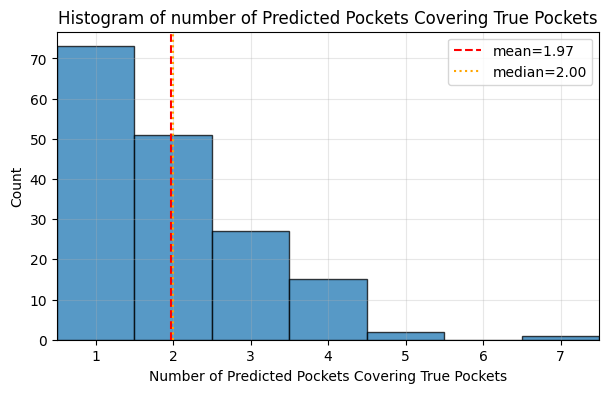

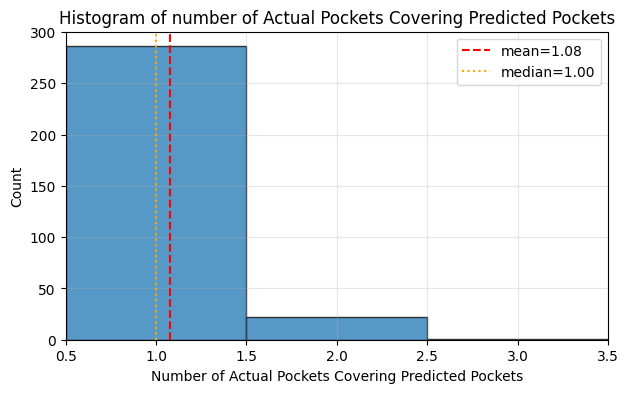

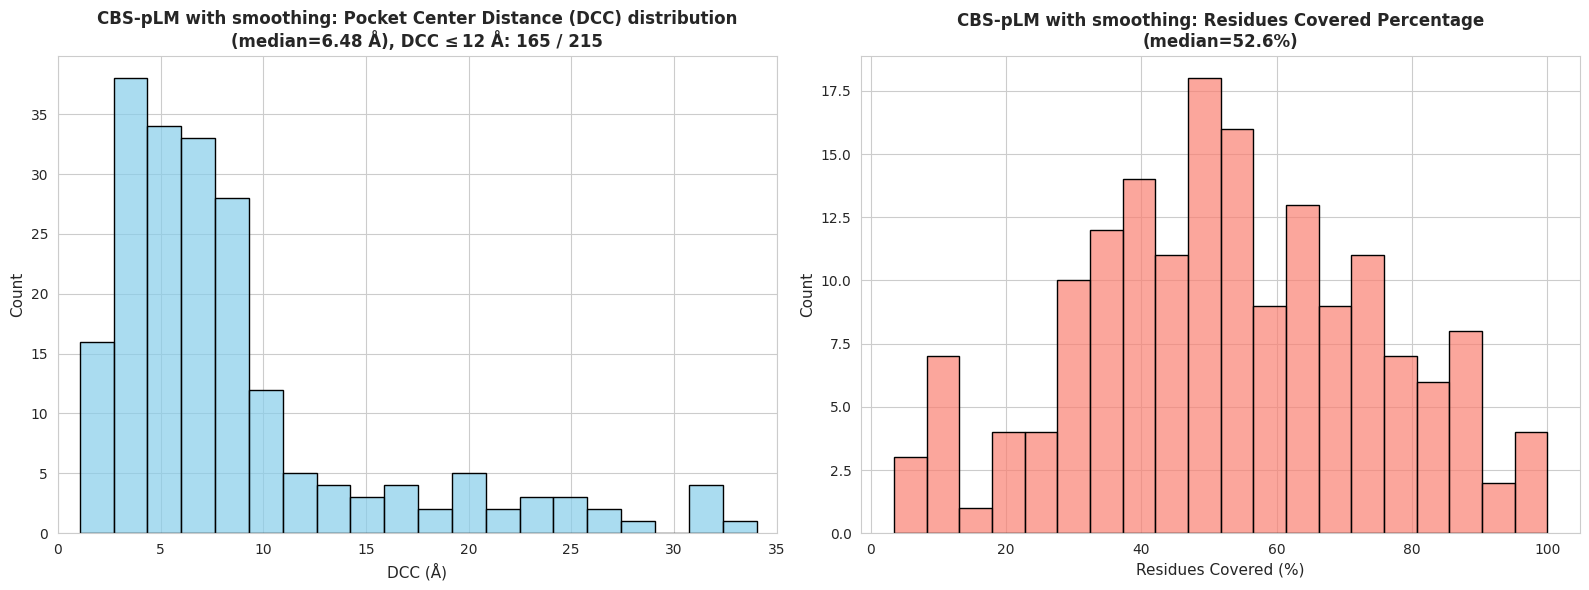

Exception ignored in: <function ResourceTracker.__del__ at 0x1476f8118ae0>
Traceback (most recent call last):
  File "/work/skrhakv/miniconda3/envs/cryptic-nn/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/work/skrhakv/miniconda3/envs/cryptic-nn/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/work/skrhakv/miniconda3/envs/cryptic-nn/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x15379b1ccae0>
Traceback (most recent call last):
  File "/work/skrhakv/miniconda3/envs/cryptic-nn/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/work/skrhakv/miniconda3/envs/cryptic-nn/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/work/skrhakv/miniconda3/envs/cryptic-nn/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _sto

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np

number_of_pockets = sum([len(i) for i in binding_residues.values()])
print('number_of_pockets: ', number_of_pockets)
mean_br = np.mean(best_residue_overlaps)
median_br = np.median(best_residue_overlaps)
print(f'best_residue_overlap mean={mean_br:.4f}, median={median_br:.4f}')

print(np.sum(np.array(DCCs) < 12) / number_of_pockets, f'({np.sum(np.array(DCCs) < 4) / number_of_pockets})')
print(np.sum(np.array(DCCs_N_plus_K) < 12) / number_of_pockets, f'({np.sum(np.array(DCCs_N_plus_K) < 4) / number_of_pockets})')
print(np.sum(np.array(DCCs_N) < 12) / number_of_pockets, f'({np.sum(np.array(DCCs_N) < 4) / number_of_pockets})')

fig, ax = plt.subplots(figsize=(7, 4))

# Remove zeros
number_of_overlapping_actual_sites_on_predicted_pocket_without_zeros = [i for i in number_of_overlapping_actual_sites_on_predicted_pocket if i != 0]
bins = np.arange(-0.5, max(number_of_overlapping_actual_sites_on_predicted_pocket_without_zeros) + 1.5, 1)
ax.clear()
ax.hist(number_of_overlapping_actual_sites_on_predicted_pocket_without_zeros, bins=bins, color='C0', edgecolor='k', alpha=0.75)
mean_cov = np.mean(number_of_overlapping_actual_sites_on_predicted_pocket_without_zeros)
median_cov = np.median(number_of_overlapping_actual_sites_on_predicted_pocket_without_zeros)
ax.axvline(mean_cov, color='red', linestyle='--', label=f"mean={mean_cov:.2f}")
ax.axvline(median_cov, color='orange', linestyle=':', label=f"median={median_cov:.2f}")
ax.set_title("Histogram of number of Predicted Pockets Covering True Pockets")
ax.set_xlim(0.5, max(number_of_overlapping_actual_sites_on_predicted_pocket_without_zeros) + 0.5)
ax.set_xlabel("Number of Predicted Pockets Covering True Pockets")
ax.set_ylabel("Count")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))

# Remove zeros
number_of_overlapping_predictions_on_actual_pocket_without_zeros = [i for i in number_of_overlapping_predictions_on_actual_pocket if i != 0]
bins = np.arange(-0.5, max(number_of_overlapping_predictions_on_actual_pocket_without_zeros) + 1.5, 1)
ax.clear()
ax.hist(number_of_overlapping_predictions_on_actual_pocket_without_zeros, bins=bins, color='C0', edgecolor='k', alpha=0.75)
mean_cov = np.mean(number_of_overlapping_predictions_on_actual_pocket_without_zeros)
median_cov = np.median(number_of_overlapping_predictions_on_actual_pocket_without_zeros)
ax.axvline(mean_cov, color='red', linestyle='--', label=f"mean={mean_cov:.2f}")
ax.axvline(median_cov, color='orange', linestyle=':', label=f"median={median_cov:.2f}")
ax.set_title("Histogram of number of Actual Pockets Covering Predicted Pockets")
ax.set_xlim(0.5, max(number_of_overlapping_predictions_on_actual_pocket_without_zeros) + 0.5)
ax.set_xlabel("Number of Actual Pockets Covering Predicted Pockets")
ax.set_ylabel("Count")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


clustering_utils.print_plots(DCCs, [i * 100 for i in best_residue_overlaps], number_of_pockets, 'CBS-pLM with smoothing', 12)

## Run clustering without smoothing

In [5]:
len(sequences)

184

In [6]:
import pickle

PRECALCULATED = False

model = torch.load(MODEL_PATH, weights_only=False)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

binding_residues, sequences = eval_utils.read_test_binding_residues(CB_PATH)

prediction_scores = {}

K = 2

DCCs_N = []
DCCs_N_plus_K = []
DCCs = []
number_of_overlapping_predictions_on_actual_pocket = []
number_of_overlapping_actual_sites_on_predicted_pocket = []
best_residue_overlaps = []

for i, protein_id in enumerate(sequences.keys()):
    print(f'Processing {protein_id} ({i+1}/{len(sequences)})...')
    pdb_id, chain_id = protein_id.split('_')
    sequence = sequences[protein_id]
    coordinates_path = f'{COORDINATES_DIR}/{pdb_id}{chain_id}.npy'
    actual_binding_sites = [np.array([int(i.split('_')[1]) for i in pocket]) for pocket in binding_residues[protein_id]]
    
    # print(f'Processing {protein_id} ({i+1}/{len(sequences)})...')
    if not PRECALCULATED:
        # finetuned prediction
        probabilities = eval_utils.compute_prediction(
            sequence,
            f'/tmp/skrhakv',
            model,
            tokenizer
        )
    else:
        # load precalculated prediction
        probabilities = np.load(f'{PRECALCULATED_PATH}/{protein_id.replace("_","")}.npy')
    
    prediction_scores[protein_id] = probabilities

    coordinates = np.load(coordinates_path)
    distance_matrix = eval_utils.compute_distance_matrix(coordinates)

    predictions = (probabilities > DECISION_THRESHOLD).astype(float)
    predictions_copy = predictions.copy()

    assert distance_matrix.shape[0] == distance_matrix.shape[1]
    assert distance_matrix.shape[0] == predictions_copy.shape[0]
    
    indices_above_threshold = np.where(predictions_copy > DECISION_THRESHOLD)[0] # this gets residues that are equal to 1
    # no predicted residues - continue
    if len(indices_above_threshold) == 0:
        print(f"Skipping {protein_id} due to no predicted binding residues.")
        continue

    # run atom-level clustering and return residue-level pockets
    clusters, cluster_residues, cluster_scores, atom_coords, residue_coords = clustering_utils.execute_atom_clustering(
        pdb_id,
        chain_id,
        indices_above_threshold,
        probabilities[indices_above_threshold],
        eps=9
    )

    # none of the residues are on the surface
    if cluster_residues is None:
        print(f"Skipping {protein_id} due to no surface binding residues.")
        continue

    cluster_residues = cryptoshow_utils.map_auth_to_mmcif_numbering_array(
        pdb_id,
        chain_id,
        cluster_residues.values(),
        binding_residues_are_integers=True,
        numbers_only=True
    )[0]

    cluster_order = np.argsort(cluster_scores)[::-1]  # descending order
    N = len(actual_binding_sites)

    selected_clusters_N = cluster_order[:N]
    selected_clusters_N_plus_K = cluster_order[:N+K]

    predicted_centers = {}
    for cluster_label, atom_indices in clusters.items():
        cluster_coords = np.array([atom_coords[atom_id] for atom_id in atom_indices])
        cluster_center = np.mean(cluster_coords, axis=0).get_array()
        predicted_centers[cluster_label] = cluster_center
    
    actual_centers = []

    for pocket in actual_binding_sites:
        pocket_coords = coordinates[pocket]
        pocket_center = np.mean(pocket_coords, axis=0)
        actual_centers.append(pocket_center)
    
    for i, center in enumerate(actual_centers):
        DCC_N = float('inf')
        for j in selected_clusters_N:
            predicted_center = predicted_centers[j]
            distance = np.linalg.norm(center - predicted_center)
            if distance < DCC_N:
                DCC_N = distance
        
        if DCC_N != float('inf'):
            DCCs_N.append(DCC_N)

        DCC_N_plus_K = float('inf')
        for j in selected_clusters_N_plus_K:
            predicted_center = predicted_centers[j]
            distance = np.linalg.norm(center - predicted_center)
            if distance < DCC_N_plus_K:
                DCC_N_plus_K = distance
        
        if DCC_N_plus_K != float('inf'):
            DCCs_N_plus_K.append(DCC_N_plus_K)

        DCC = float('inf')
        for j, predicted_center in predicted_centers.items():
            distance = np.linalg.norm(center - predicted_center)
            if distance < DCC:
                DCC = distance    

        if DCC != float('inf'):
            DCCs.append(DCC)

    for pocket in actual_binding_sites:
        number_of_predicted_pockets = 0
        best_residue_overlap = 0
        for residues in cluster_residues:
            residue_overlap = len(set(pocket).intersection(residues)) / len(pocket)
            if residue_overlap > best_residue_overlap:
                best_residue_overlap = residue_overlap
            if any(residue in pocket for residue in residues):
                number_of_predicted_pockets += 1
        number_of_overlapping_actual_sites_on_predicted_pocket.append(number_of_predicted_pockets)
        if best_residue_overlap > 0:
            best_residue_overlaps.append(best_residue_overlap)

    for residues in cluster_residues:
        number_of_predicted_pockets = 0
        for pocket in actual_binding_sites:
            if any(residue in pocket for residue in residues):
                number_of_predicted_pockets += 1
        number_of_overlapping_predictions_on_actual_pocket.append(number_of_predicted_pockets)

    with open(f'{PATH}/data/predictions/cbs-model-without-smoothing-with-clustering/{protein_id}.pkl', 'wb') as f:
        pickle.dump(cluster_residues, f)

Processing 7qoq_A (1/184)...
Processing 8i84_B (2/184)...
Processing 5igh_A (3/184)...
Processing 7w19_A (4/184)...
Processing 5uxa_A (5/184)...
Processing 3h8a_B (6/184)...
Processing 6isu_A (7/184)...
Processing 5yhb_A (8/184)...
Skipping 5yhb_A due to no predicted binding residues.
Processing 3rwv_A (9/184)...
Processing 2i3a_D (10/184)...
Processing 4oqo_B (11/184)...
Processing 3gdg_B (12/184)...
Processing 1kx9_A (13/184)...
Processing 1kxr_A (14/184)...
Processing 1ute_A (15/184)...
Processing 7f4y_B (16/184)...
Processing 7nlx_A (17/184)...
Processing 1se8_A (18/184)...
Processing 7xgf_E (19/184)...
Processing 5yj2_C (20/184)...
Processing 7e5q_B (21/184)...
Processing 5e0v_A (22/184)...
Skipping 5e0v_A due to no predicted binding residues.
Processing 6jq9_B (23/184)...
Processing 7o1i_A (24/184)...
Processing 3ly8_A (25/184)...
Skipping 3ly8_A due to no predicted binding residues.
Processing 1bzj_A (26/184)...
Processing 7c63_A (27/184)...
Processing 7x0i_B (28/184)...
Process

best_residue_overlap mean=0.4921, median=0.4749
0.7488372093023256 (0.20465116279069767)
0.7488372093023256 (0.20465116279069767)
0.6465116279069767 (0.16744186046511628)


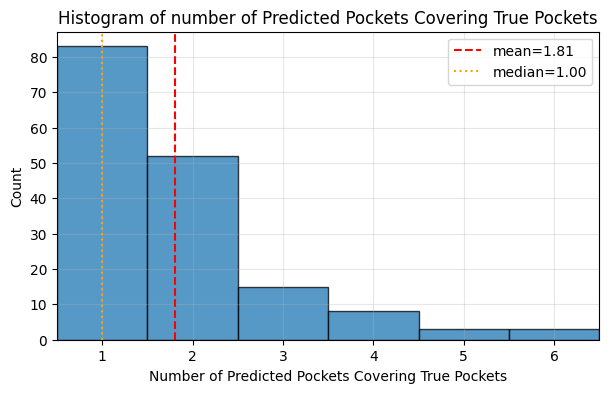

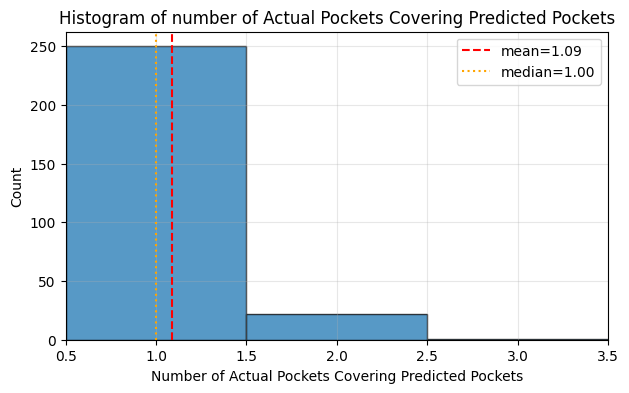

In [7]:
import numpy as np
import matplotlib.pyplot as plt

number_of_pockets = sum([len(i) for i in binding_residues.values()])

mean_br = np.mean(best_residue_overlaps)
median_br = np.median(best_residue_overlaps)
print(f'best_residue_overlap mean={mean_br:.4f}, median={median_br:.4f}')
print(np.sum(np.array(DCCs) < 12) / number_of_pockets, f'({np.sum(np.array(DCCs) < 4) / number_of_pockets})')
print(np.sum(np.array(DCCs_N_plus_K) < 12) / number_of_pockets, f'({np.sum(np.array(DCCs_N_plus_K) < 4) / number_of_pockets})')
print(np.sum(np.array(DCCs_N) < 12) / number_of_pockets, f'({np.sum(np.array(DCCs_N) < 4) / number_of_pockets})')

fig, ax = plt.subplots(figsize=(7, 4))

# Remove zeros
number_of_overlapping_actual_sites_on_predicted_pocket_without_zeros = [i for i in number_of_overlapping_actual_sites_on_predicted_pocket if i != 0]
bins = np.arange(-0.5, max(number_of_overlapping_actual_sites_on_predicted_pocket_without_zeros) + 1.5, 1)
ax.clear()
ax.hist(number_of_overlapping_actual_sites_on_predicted_pocket_without_zeros, bins=bins, color='C0', edgecolor='k', alpha=0.75)
mean_cov = np.mean(number_of_overlapping_actual_sites_on_predicted_pocket_without_zeros)
median_cov = np.median(number_of_overlapping_actual_sites_on_predicted_pocket_without_zeros)
ax.axvline(mean_cov, color='red', linestyle='--', label=f"mean={mean_cov:.2f}")
ax.axvline(median_cov, color='orange', linestyle=':', label=f"median={median_cov:.2f}")
ax.set_title("Histogram of number of Predicted Pockets Covering True Pockets")
ax.set_xlim(0.5, max(number_of_overlapping_actual_sites_on_predicted_pocket_without_zeros) + 0.5)
ax.set_xlabel("Number of Predicted Pockets Covering True Pockets")
ax.set_ylabel("Count")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))

# Remove zeros
number_of_overlapping_predictions_on_actual_pocket_without_zeros = [i for i in number_of_overlapping_predictions_on_actual_pocket if i != 0]
bins = np.arange(-0.5, max(number_of_overlapping_predictions_on_actual_pocket_without_zeros) + 1.5, 1)
ax.clear()
ax.hist(number_of_overlapping_predictions_on_actual_pocket_without_zeros, bins=bins, color='C0', edgecolor='k', alpha=0.75)
mean_cov = np.mean(number_of_overlapping_predictions_on_actual_pocket_without_zeros)
median_cov = np.median(number_of_overlapping_predictions_on_actual_pocket_without_zeros)
ax.axvline(mean_cov, color='red', linestyle='--', label=f"mean={mean_cov:.2f}")
ax.axvline(median_cov, color='orange', linestyle=':', label=f"median={median_cov:.2f}")
ax.set_title("Histogram of number of Actual Pockets Covering Predicted Pockets")
ax.set_xlim(0.5, max(number_of_overlapping_predictions_on_actual_pocket_without_zeros) + 0.5)
ax.set_xlabel("Number of Actual Pockets Covering Predicted Pockets")
ax.set_ylabel("Count")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## Merge p2rank with pLM
Take the smoothed pLM predictions, merge them with p2rank and measure the DCC and RRO.

In [ ]:
import pickle
import os

cryptic_binding_residues, sequences = eval_utils.read_test_binding_residues()
cryptic_binding_residues = {key.replace('_', ''):value for key, value in cryptic_binding_residues.items()}

with open('/home/skrhakv/cryptoshow-analysis/data/data-extraction/predicted_pockets_p2rank.pkl', 'rb') as f:
    p2rank_predictions = pickle.load(f)
    # reformat in order to have the same format as predicted_binding_sites - dictionary of numpy arrays
    p2rank_predictions = {key.replace('_', ''):[np.array([int(ii[1:]) for ii in i]) for i in predicted_pockets] for key, predicted_pockets in p2rank_predictions.items()}

pLM_prediction_path = '/home/skrhakv/cryptoshow-analysis/data/visualizations/predictions/cryptobench-with-clustering'
predicted_binding_sites = {}
for file in os.listdir(pLM_prediction_path):
    if not file.endswith('.pkl'):
        continue
    protein_id = file.split('.')[0]
    with open(f'{pLM_prediction_path}/{file}', 'rb') as f:
        cluster_residues, _ = pickle.load(f)
        predicted_binding_sites[protein_id] = []
        for residues in cluster_residues:
            predicted_binding_sites[protein_id].append((np.array(residues), 'finetuned model with smoothing'))

def merge_predictions(predicted_binding_sites: dict[str, list[tuple[np.ndarray, str]]], p2rank_predictions: dict[str, list[np.ndarray]]):
    """
    Merge the predicted binding sites from the finetuned model and p2rank.

    Args:
        predicted_binding_sites (dict): Dictionary where keys are protein IDs and values are lists of tuples (binding_site_indices, 'finetuned model with smoothing').
        p2rank_predictions (dict): Dictionary where keys are protein IDs and values are lists of numpy arrays of binding site indices predicted by p2rank.

    Returns:
        dict: Merged dictionary with keys as protein IDs and values as lists of tuples (binding_site_indices, source).
    """
    merged_predictions = {}
    for protein_id in sequences.keys():
        protein_id = protein_id.replace('_', '')
        merged_predictions[protein_id] = []
        # add finetuned model predictions
        if protein_id in predicted_binding_sites:
            for binding_sites in predicted_binding_sites[protein_id]:
                merged_predictions[protein_id].append(binding_sites)
        # add p2rank predictions
        if protein_id in p2rank_predictions:
            for binding_sites in p2rank_predictions[protein_id]:
                merged_predictions[protein_id].append((binding_sites, 'p2rank'))
    return merged_predictions

merged_predictions = merge_predictions(predicted_binding_sites, p2rank_predictions)

In [ ]:
ESM_EMBEDDINGS_PATH = '/home/skrhakv/cryptoshow-analysis/data/embeddings/cryptobench'
COORDINATES_DIR = '/home/skrhakv/cryptoshow-analysis/data/coordinates/cryptobench'
POSITIVE_DISTANCE_THRESHOLD = 15
PRECALCULATED = True
PRECALCULATED_PATH = '/home/skrhakv/cryptoshow-analysis/data-old/B-evaluate-cryptoshow/predictions/finetuning-without-smoothing'
DECISION_THRESHOLD = 0.7

model = torch.load(MODEL_PATH, weights_only=False)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

binding_residues, sequences = eval_utils.read_test_binding_residues()

predicted_binding_sites = {}
ranks = {}
prediction_scores = {}

K = 2

DCCs_N = []
DCCs_N_plus_K = []
DCCs = []
number_of_overlapping_predictions_on_actual_pocket = []
number_of_overlapping_actual_sites_on_predicted_pocket = []
best_residue_overlaps = []

for i, protein_id in enumerate(sequences.keys()):
    pdb_id, chain_id = protein_id.split('_')
    sequence = sequences[protein_id]
    embeddings_path = f'{ESM_EMBEDDINGS_PATH}/{pdb_id}{chain_id}.npy'
    coordinates_path = f'{COORDINATES_DIR}/{pdb_id}{chain_id}.npy'
    actual_binding_sites = [np.array([int(i.split('_')[1]) for i in pocket]) for pocket in binding_residues[protein_id]]
    
    print(f'Processing {protein_id} ({i+1}/{len(sequences)})...')
    if not PRECALCULATED:
        # finetuned prediction
        probabilities = eval_utils.compute_prediction(
            sequence,
            f'/tmp/skrhakv',
            model,
            tokenizer
        )
    else:
        # load precalculated prediction
        probabilities = np.load(f'{PRECALCULATED_PATH}/{protein_id.replace("_","")}.npy')
    
    prediction_scores[protein_id] = probabilities

    coordinates = np.load(coordinates_path)
    distance_matrix = eval_utils.compute_distance_matrix(coordinates)

    predictions = (probabilities > DECISION_THRESHOLD).astype(float)
    predictions_copy = predictions.copy()

    assert distance_matrix.shape[0] == distance_matrix.shape[1]
    assert distance_matrix.shape[0] == predictions_copy.shape[0]
    
    X_test = np.load(embeddings_path)
    if X_test.shape[0] != distance_matrix.shape[0]:
        print(f"Skipping {protein_id} due to embedding/coordinate size mismatch.")
        continue
    # assert X_test.shape[0] == distance_matrix.shape[0]

    # loop over the residues that are not binding and are potential candidates for smoothing
    additional_residues = []
    for residue_idx in np.where(predictions == 0.0)[0]:

        # get the embedding of the residue
        current_residue_embedding = X_test[residue_idx]

        # get the close binding residues
        close_residues_indices = np.where(distance_matrix[residue_idx] < POSITIVE_DISTANCE_THRESHOLD)[0]
        close_binding_residues_indices = np.intersect1d(close_residues_indices, np.where(predictions == 1.0)[0])
        # create embedding 
        if len(close_binding_residues_indices) == 0:
            # no close binding residues - skip this residue
            continue
        elif len(close_binding_residues_indices) == 1:
            surrounding_embedding = X_test[close_binding_residues_indices].reshape(-1)
        else:
            # get the mean of the close binding residues
            surrounding_embedding = np.mean(X_test[close_binding_residues_indices], axis=0).reshape(-1)

        concatenated_embedding = torch.tensor(np.concatenate((current_residue_embedding, surrounding_embedding), axis=0), dtype=torch.float32).to(device)
        
        # get the prediction
        test_logits = smoothing_model(concatenated_embedding).squeeze()
        result = (torch.sigmoid(test_logits)>eval_utils.SMOOTHING_DECISION_THRESHOLD).float()
        if result == 1:
            # set the residue as binding
            print(f"Smoothing changed residue {residue_idx} in protein {protein_id} to binding")
            additional_residues.append(residue_idx)
            predictions_copy[residue_idx] = 1

    indices_above_threshold = np.where(predictions_copy > DECISION_THRESHOLD)[0] # this gets residues that are equal to 1
    # no predicted residues - continue
    if len(indices_above_threshold) == 0:
        continue

    # run atom-level clustering and return residue-level pockets
    clusters, cluster_residues, cluster_scores, atom_coords, residue_coords = clustering_utils.execute_atom_clustering(
        pdb_id,
        chain_id,
        indices_above_threshold,
        probabilities[indices_above_threshold],
        eps=9
    )

    # none of the residues are on the surface
    if cluster_residues is None:
        continue

    cluster_residues = cryptoshow_utils.map_auth_to_mmcif_numbering_array(
        pdb_id,
        chain_id,
        cluster_residues.values(),
        binding_residues_are_integers=True,
        numbers_only=True
    )[0]

    cluster_order = np.argsort(cluster_scores)[::-1]  # descending order
    N = len(actual_binding_sites)

    selected_clusters_N = cluster_order[:N]
    selected_clusters_N_plus_K = cluster_order[:N+K]

    predicted_centers = {}
    for cluster_label, atom_indices in clusters.items():
        cluster_coords = np.array([atom_coords[atom_id] for atom_id in atom_indices])
        cluster_center = np.mean(cluster_coords, axis=0).get_array()
        predicted_centers[cluster_label] = cluster_center
    
    actual_centers = []
    for pocket in actual_binding_sites:
        pocket_coords = coordinates[pocket]
        pocket_center = np.mean(pocket_coords, axis=0)
        actual_centers.append(pocket_center)
    
    p2rank_centers = []
    protein_id_nounderscore = protein_id.replace('_', '')
    for pocket in p2rank_predictions[protein_id_nounderscore]:
        pocket_coords = coordinates[pocket]
        pocket_center = np.mean(pocket_coords, axis=0)
        p2rank_centers.append(pocket_center)

    for i, center in enumerate(actual_centers):
        DCC = float('inf')
        for j, predicted_center in predicted_centers.items():
            distance = np.linalg.norm(center - predicted_center)
            if distance < DCC:
                DCC = distance    
        for j in p2rank_centers:
            distance = np.linalg.norm(center - j)
            if distance < DCC:
                DCC = distance
        
        if DCC != float('inf'):
            DCCs.append(DCC)

    for pocket in actual_binding_sites:
        best_residue_overlap = 0
        # compute RRO for pLM predictions
        for residues in cluster_residues:
            residue_overlap = len(set(pocket).intersection(residues)) / len(pocket)
            if residue_overlap > best_residue_overlap:
                best_residue_overlap = residue_overlap
        # compute RRO for p2rank predictions
        for residues in p2rank_predictions[protein_id_nounderscore]:
            residue_overlap = len(set(pocket).intersection(residues)) / len(pocket)
            if residue_overlap > best_residue_overlap:
                best_residue_overlap = residue_overlap
        # save best RRO
        if best_residue_overlap > 0:
            best_residue_overlaps.append(best_residue_overlap)



Processing 7qoq_A (1/184)...
Smoothing changed residue 48 in protein 7qoq_A to binding
Smoothing changed residue 70 in protein 7qoq_A to binding
Smoothing changed residue 71 in protein 7qoq_A to binding
Smoothing changed residue 74 in protein 7qoq_A to binding
Smoothing changed residue 76 in protein 7qoq_A to binding
Smoothing changed residue 106 in protein 7qoq_A to binding
Processing 8i84_B (2/184)...
Smoothing changed residue 38 in protein 8i84_B to binding
Smoothing changed residue 88 in protein 8i84_B to binding
Smoothing changed residue 91 in protein 8i84_B to binding
Smoothing changed residue 96 in protein 8i84_B to binding
Smoothing changed residue 97 in protein 8i84_B to binding
Smoothing changed residue 98 in protein 8i84_B to binding
Smoothing changed residue 191 in protein 8i84_B to binding
Smoothing changed residue 206 in protein 8i84_B to binding
Smoothing changed residue 263 in protein 8i84_B to binding
Processing 5igh_A (3/184)...
Smoothing changed residue 53 in protein

best_residue_overlap mean=0.5877, median=0.6099
0.8093023255813954 (0.31627906976744186)


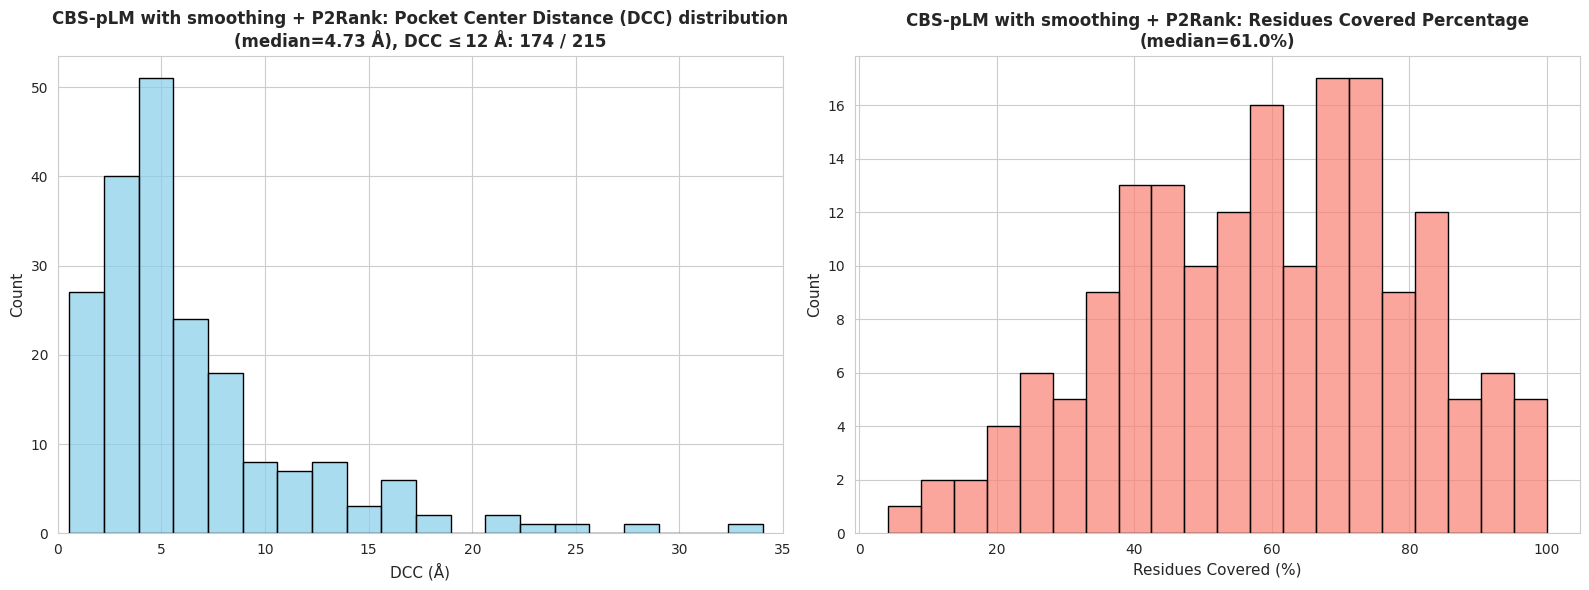

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np

number_of_pockets = sum([len(i) for i in binding_residues.values()])

mean_br = np.mean(best_residue_overlaps)
median_br = np.median(best_residue_overlaps)
print(f'best_residue_overlap mean={mean_br:.4f}, median={median_br:.4f}')

print(np.sum(np.array(DCCs) < 12) / number_of_pockets, f'({np.sum(np.array(DCCs) < 4) / number_of_pockets})')

clustering_utils.print_plots(DCCs, [i * 100 for i in best_residue_overlaps], number_of_pockets, 'CBS-pLM with smoothing + P2Rank', 12)

In [ ]:
sys.path.append('/home/skrhakv/cryptic-nn/src')
from baseline_utils import CryptoBenchClassifier

MODEL_PATH = '/home/skrhakv/cryptoshow-analysis/data/models/cryptobench-baseline.pt'
ESM_EMBEDDINGS_PATH = '/home/skrhakv/cryptoshow-analysis/data/embeddings/cryptobench'
COORDINATES_DIR = '/home/skrhakv/cryptoshow-analysis/data/coordinates/cryptobench'
DECISION_THRESHOLD = 0.95


baseline_model = torch.load(MODEL_PATH, weights_only=False)

binding_residues, sequences = eval_utils.read_test_binding_residues()

predicted_binding_sites = {}
ranks = {}
prediction_scores = {}

K = 2

DCCs_N = []
DCCs_N_plus_K = []
DCCs = []
number_of_overlapping_predictions_on_actual_pocket = []
number_of_overlapping_actual_sites_on_predicted_pocket = []
best_residue_overlaps = []

for i, protein_id in enumerate(sequences.keys()):
    pdb_id, chain_id = protein_id.split('_')
    sequence = sequences[protein_id]
    embeddings_path = f'{ESM_EMBEDDINGS_PATH}/{pdb_id}{chain_id}.npy'
    coordinates_path = f'{COORDINATES_DIR}/{pdb_id}{chain_id}.npy'
    actual_binding_sites = [np.array([int(i.split('_')[1]) for i in pocket]) for pocket in binding_residues[protein_id]]
    
    input_embeddings = torch.tensor(np.load(embeddings_path)).to(device) 
    test_logits = baseline_model(input_embeddings)  
    probabilities = torch.sigmoid(test_logits).detach().cpu().numpy()
  
    prediction_scores[protein_id] = probabilities

    coordinates = np.load(coordinates_path)
    distance_matrix = eval_utils.compute_distance_matrix(coordinates)

    predictions = (probabilities > DECISION_THRESHOLD).astype(float)
    predictions_copy = predictions.copy()

    assert input_embeddings.shape[0] == distance_matrix.shape[0], f"Embedding/coordinate size mismatch for {protein_id}"
    assert distance_matrix.shape[0] == distance_matrix.shape[1]
    assert distance_matrix.shape[0] == predictions_copy.shape[0]
    
    indices_above_threshold = np.where(predictions_copy > DECISION_THRESHOLD)[0] # '[0]' gets residues that are equal to 1
    # no predicted residues - continue
    if len(indices_above_threshold) == 0:
        print(f"Skipping {protein_id} due to no predicted binding residues.")
        continue

    # run atom-level clustering and return residue-level pockets
    clusters, cluster_residues, cluster_scores, atom_coords, residue_coords = clustering_utils.execute_atom_clustering(
        pdb_id,
        chain_id,
        indices_above_threshold,
        probabilities[indices_above_threshold],
        eps=9
    )

    # none of the residues are on the surface
    if cluster_residues is None:
        print(f"Skipping {protein_id} due to no surface binding residues.")
        continue

    cluster_residues = cryptoshow_utils.map_auth_to_mmcif_numbering_array(
        pdb_id,
        chain_id,
        cluster_residues.values(),
        binding_residues_are_integers=True,
        numbers_only=True
    )[0]

    cluster_order = np.argsort(cluster_scores)[::-1]  # descending order
    N = len(actual_binding_sites)

    selected_clusters_N = cluster_order[:N]
    selected_clusters_N_plus_K = cluster_order[:N+K]

    predicted_centers = {}
    for cluster_label, atom_indices in clusters.items():
        cluster_coords = np.array([atom_coords[atom_id] for atom_id in atom_indices])
        cluster_center = np.mean(cluster_coords, axis=0).get_array()
        predicted_centers[cluster_label] = cluster_center
    
    actual_centers = []

    for pocket in actual_binding_sites:
        pocket_coords = coordinates[pocket]
        pocket_center = np.mean(pocket_coords, axis=0)
        actual_centers.append(pocket_center)
    
    for i, center in enumerate(actual_centers):
        DCC_N = float('inf')
        for j in selected_clusters_N:
            predicted_center = predicted_centers[j]
            distance = np.linalg.norm(center - predicted_center)
            if distance < DCC_N:
                DCC_N = distance
        
        if DCC_N != float('inf'):
            DCCs_N.append(DCC_N)

        DCC_N_plus_K = float('inf')
        for j in selected_clusters_N_plus_K:
            predicted_center = predicted_centers[j]
            distance = np.linalg.norm(center - predicted_center)
            if distance < DCC_N_plus_K:
                DCC_N_plus_K = distance
        
        if DCC_N_plus_K != float('inf'):
            DCCs_N_plus_K.append(DCC_N_plus_K)

        DCC = float('inf')
        for j, predicted_center in predicted_centers.items():
            distance = np.linalg.norm(center - predicted_center)
            if distance < DCC:
                DCC = distance    

        if DCC != float('inf'):
            DCCs.append(DCC)

    for pocket in actual_binding_sites:
        number_of_predicted_pockets = 0
        best_residue_overlap = 0
        for residues in cluster_residues:
            residue_overlap = len(set(pocket).intersection(residues)) / len(pocket)
            if residue_overlap > best_residue_overlap:
                best_residue_overlap = residue_overlap
            if any(residue in pocket for residue in residues):
                number_of_predicted_pockets += 1
        number_of_overlapping_actual_sites_on_predicted_pocket.append(number_of_predicted_pockets)
        if best_residue_overlap > 0:
            best_residue_overlaps.append(best_residue_overlap)

    for residues in cluster_residues:
        number_of_predicted_pockets = 0
        for pocket in actual_binding_sites:
            if any(residue in pocket for residue in residues):
                number_of_predicted_pockets += 1
        number_of_overlapping_predictions_on_actual_pocket.append(number_of_predicted_pockets)

Skipping 5yhb_A due to no predicted binding residues.
Skipping 4uc8_A due to no predicted binding residues.
Skipping 5caz_A due to no predicted binding residues.
Skipping 2vqz_F due to no predicted binding residues.
Skipping 5o8b_A due to no predicted binding residues.


best_residue_overlap mean=0.4212, median=0.4167
0.7534883720930232 (0.15813953488372093)
0.7302325581395349 (0.15813953488372093)
0.6186046511627907 (0.09767441860465116)


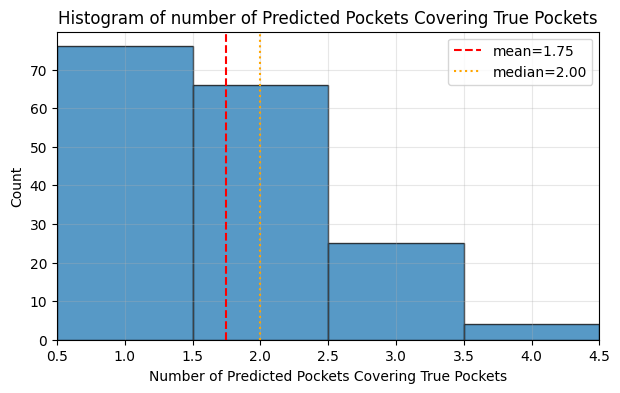

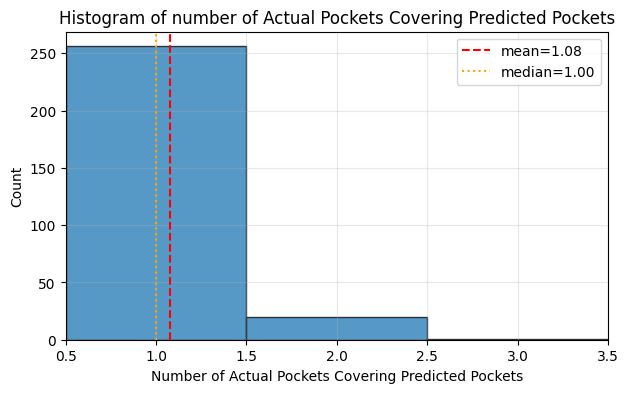

In [20]:
import numpy as np
import matplotlib.pyplot as plt

number_of_pockets = sum([len(i) for i in binding_residues.values()])

mean_br = np.mean(best_residue_overlaps)
median_br = np.median(best_residue_overlaps)
print(f'best_residue_overlap mean={mean_br:.4f}, median={median_br:.4f}')
print(np.sum(np.array(DCCs) < 12) / number_of_pockets, f'({np.sum(np.array(DCCs) < 4) / number_of_pockets})')
print(np.sum(np.array(DCCs_N_plus_K) < 12) / number_of_pockets, f'({np.sum(np.array(DCCs_N_plus_K) < 4) / number_of_pockets})')
print(np.sum(np.array(DCCs_N) < 12) / number_of_pockets, f'({np.sum(np.array(DCCs_N) < 4) / number_of_pockets})')

fig, ax = plt.subplots(figsize=(7, 4))

# Remove zeros
number_of_overlapping_actual_sites_on_predicted_pocket_without_zeros = [i for i in number_of_overlapping_actual_sites_on_predicted_pocket if i != 0]
bins = np.arange(-0.5, max(number_of_overlapping_actual_sites_on_predicted_pocket_without_zeros) + 1.5, 1)
ax.clear()
ax.hist(number_of_overlapping_actual_sites_on_predicted_pocket_without_zeros, bins=bins, color='C0', edgecolor='k', alpha=0.75)
mean_cov = np.mean(number_of_overlapping_actual_sites_on_predicted_pocket_without_zeros)
median_cov = np.median(number_of_overlapping_actual_sites_on_predicted_pocket_without_zeros)
ax.axvline(mean_cov, color='red', linestyle='--', label=f"mean={mean_cov:.2f}")
ax.axvline(median_cov, color='orange', linestyle=':', label=f"median={median_cov:.2f}")
ax.set_title("Histogram of number of Predicted Pockets Covering True Pockets")
ax.set_xlim(0.5, max(number_of_overlapping_actual_sites_on_predicted_pocket_without_zeros) + 0.5)
ax.set_xlabel("Number of Predicted Pockets Covering True Pockets")
ax.set_ylabel("Count")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))

# Remove zeros
number_of_overlapping_predictions_on_actual_pocket_without_zeros = [i for i in number_of_overlapping_predictions_on_actual_pocket if i != 0]
bins = np.arange(-0.5, max(number_of_overlapping_predictions_on_actual_pocket_without_zeros) + 1.5, 1)
ax.clear()
ax.hist(number_of_overlapping_predictions_on_actual_pocket_without_zeros, bins=bins, color='C0', edgecolor='k', alpha=0.75)
mean_cov = np.mean(number_of_overlapping_predictions_on_actual_pocket_without_zeros)
median_cov = np.median(number_of_overlapping_predictions_on_actual_pocket_without_zeros)
ax.axvline(mean_cov, color='red', linestyle='--', label=f"mean={mean_cov:.2f}")
ax.axvline(median_cov, color='orange', linestyle=':', label=f"median={median_cov:.2f}")
ax.set_title("Histogram of number of Actual Pockets Covering Predicted Pockets")
ax.set_xlim(0.5, max(number_of_overlapping_predictions_on_actual_pocket_without_zeros) + 0.5)
ax.set_xlabel("Number of Actual Pockets Covering Predicted Pockets")
ax.set_ylabel("Count")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

# best_residue_overlap mean=0.4164, median=0.4120
# 0.7581395348837209 (0.16279069767441862)
# 0.7441860465116279 (0.15813953488372093)
# 0.6046511627906976 (0.10697674418604651)

## Run 650M version

In [4]:
PREDICTIONS_PATH = f'{PATH}/data/predictions'
PRECALCULATED_PATH = f'{PREDICTIONS_PATH}/cbs-model-650M'

MODEL_PATH = f'{PATH}/data/models/cbs-model-650M.pt'
PRECALCULATED = False
SMOOTHING_MODEL_PATH = f'{PATH}/data/models/smoother-650M.pt'
ESM_EMBEDDINGS_PATH = f'{PATH}/data/embeddings/cryptobench-650M'
MODEL_NAME = 'facebook/esm2_t33_650M_UR50D'


OUTPUT_SIZE = 1
DROPOUT = 0.25
from transformers import AutoTokenizer, EsmModel
import torch.nn as nn
class FinetuneESM(nn.Module):
    def __init__(self, esm_model: str) -> None:
        super().__init__()
        self.llm = EsmModel.from_pretrained(esm_model)
        self.dropout = nn.Dropout(DROPOUT)
        self.classifier = nn.Linear(self.llm.config.hidden_size, OUTPUT_SIZE)
        self.plDDT_regressor = nn.Linear(self.llm.config.hidden_size, OUTPUT_SIZE)
        self.distance_regressor = nn.Linear(self.llm.config.hidden_size, OUTPUT_SIZE)

    def forward(self, batch: dict[str, np.ndarray]) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        input_ids, attention_mask = batch["input_ids"], batch["attention_mask"]
        token_embeddings = self.llm(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state

        return (
            self.classifier(token_embeddings),
            self.plDDT_regressor(token_embeddings),
            self.distance_regressor(token_embeddings),
        )

smoothing_model = torch.load(SMOOTHING_MODEL_PATH, weights_only=False) #, map_location=torch.device('cpu'))

model = torch.load(MODEL_PATH, weights_only=False)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

binding_residues, sequences = eval_utils.read_test_binding_residues(data_path=CB_PATH)

predicted_binding_sites = {}
ranks = {}
prediction_scores = {}

K = 2

DCCs_N = []
DCCs_N_plus_K = []
DCCs = []

is_small_pocket_DCC_N = []
is_small_pocket_DCC_N_plus_K = []
is_small_pocket_DCC = []

number_of_added_residues = []

number_of_overlapping_predictions_on_actual_pocket = []
number_of_overlapping_actual_sites_on_predicted_pocket = []
best_residue_overlaps = []

for i, protein_id in enumerate(sequences.keys()):
    pdb_id, chain_id = protein_id.split('_')
    sequence = sequences[protein_id]
    embeddings_path = f'{ESM_EMBEDDINGS_PATH}/{pdb_id}{chain_id}.npy'
    coordinates_path = f'{COORDINATES_DIR}/{pdb_id}{chain_id}.npy'
    actual_binding_sites = [np.array([int(i.split('_')[1]) for i in pocket]) for pocket in binding_residues[protein_id]]
    
    print(f'Processing {protein_id} ({i+1}/{len(sequences)})...')
    if not PRECALCULATED:
        # finetuned prediction
        probabilities = eval_utils.compute_prediction(
            sequence,
            f'/tmp/skrhakv',
            model,
            tokenizer
        )
    else:
        # load precalculated prediction
        probabilities = np.load(f'{PRECALCULATED_PATH}/{protein_id.replace("_","")}.npy')
    
    prediction_scores[protein_id] = probabilities

    coordinates = np.load(coordinates_path)
    distance_matrix = eval_utils.compute_distance_matrix(coordinates)

    predictions = (probabilities > DECISION_THRESHOLD).astype(float)
    predictions_copy = predictions.copy()

    assert distance_matrix.shape[0] == distance_matrix.shape[1]
    assert distance_matrix.shape[0] == predictions_copy.shape[0]
    
    X_test = np.load(embeddings_path)
    assert X_test.shape[0] == distance_matrix.shape[0]

    # loop over the residues that are not binding and are potential candidates for smoothing
    additional_residues = []
    added_residues_count = 0
    for residue_idx in np.where(predictions == 0.0)[0]:

        # get the embedding of the residue
        current_residue_embedding = X_test[residue_idx]

        # get the close binding residues
        close_residues_indices = np.where(distance_matrix[residue_idx] < POSITIVE_DISTANCE_THRESHOLD)[0]
        close_binding_residues_indices = np.intersect1d(close_residues_indices, np.where(predictions == 1.0)[0])
        # create embedding 
        if len(close_binding_residues_indices) == 0:
            # no close binding residues - skip this residue
            continue
        elif len(close_binding_residues_indices) == 1:
            surrounding_embedding = X_test[close_binding_residues_indices].reshape(-1)
        else:
            # get the mean of the close binding residues
            surrounding_embedding = np.mean(X_test[close_binding_residues_indices], axis=0).reshape(-1)

        concatenated_embedding = torch.tensor(np.concatenate((current_residue_embedding, surrounding_embedding), axis=0), dtype=torch.float32).to(device)
        
        # get the prediction
        test_logits = smoothing_model(concatenated_embedding).squeeze()
        result = (torch.sigmoid(test_logits)>eval_utils.SMOOTHING_DECISION_THRESHOLD).float()
        if result == 1:
            # set the residue as binding
            # print(f"Smoothing changed residue {residue_idx} in protein {protein_id} to binding")
            additional_residues.append(residue_idx)
            predictions_copy[residue_idx] = 1
            added_residues_count += 1

    number_of_added_residues.append(added_residues_count)
    
    indices_above_threshold = np.where(predictions_copy > DECISION_THRESHOLD)[0] # this gets residues that are equal to 1
    # no predicted residues - continue
    if len(indices_above_threshold) == 0:
        continue

    # run atom-level clustering and return residue-level pockets
    clusters, cluster_residues, cluster_scores, atom_coords, residue_coords = clustering_utils.execute_atom_clustering(
        pdb_id,
        chain_id,
        indices_above_threshold,
        probabilities[indices_above_threshold],
        eps=9
    )

    # none of the residues are on the surface
    if cluster_residues is None:
        continue

    cluster_residues = cryptoshow_utils.map_auth_to_mmcif_numbering_array(
        pdb_id,
        chain_id,
        cluster_residues.values(),
        binding_residues_are_integers=True,
        numbers_only=True
    )[0]

    cluster_order = np.argsort(cluster_scores)[::-1]  # descending order
    N = len(actual_binding_sites)

    selected_clusters_N = cluster_order[:N]
    selected_clusters_N_plus_K = cluster_order[:N+K]

    predicted_centers = {}
    for cluster_label, atom_indices in clusters.items():
        cluster_coords = np.array([atom_coords[atom_id] for atom_id in atom_indices])
        cluster_center = np.mean(cluster_coords, axis=0).get_array()
        predicted_centers[cluster_label] = cluster_center
    
    actual_centers = []
    is_small_pocket = []
    for pocket in actual_binding_sites:
        pocket_coords = coordinates[pocket]
        pocket_center = np.mean(pocket_coords, axis=0)
        actual_centers.append(pocket_center)
        is_small_pocket.append(len(pocket) < 10)
    
    for i, center in enumerate(actual_centers):
        DCC_N = float('inf')
        for j in selected_clusters_N:
            predicted_center = predicted_centers[j]
            distance = np.linalg.norm(center - predicted_center)
            if distance < DCC_N:
                DCC_N = distance
        
        if DCC_N != float('inf'):
            DCCs_N.append(DCC_N)
            is_small_pocket_DCC_N.append(is_small_pocket[i])

        DCC_N_plus_K = float('inf')
        for j in selected_clusters_N_plus_K:
            predicted_center = predicted_centers[j]
            distance = np.linalg.norm(center - predicted_center)
            if distance < DCC_N_plus_K:
                DCC_N_plus_K = distance
        
        if DCC_N_plus_K != float('inf'):
            DCCs_N_plus_K.append(DCC_N_plus_K)
            is_small_pocket_DCC_N_plus_K.append(is_small_pocket[i])
            
        DCC = float('inf')
        for j, predicted_center in predicted_centers.items():
            distance = np.linalg.norm(center - predicted_center)
            if distance < DCC:
                DCC = distance    

        if DCC != float('inf'):
            DCCs.append(DCC)
            is_small_pocket_DCC.append(is_small_pocket[i])

    for pocket in actual_binding_sites:
        number_of_predicted_pockets = 0
        best_residue_overlap = 0
        for residues in cluster_residues:
            residue_overlap = len(set(pocket).intersection(residues)) / len(pocket)
            if residue_overlap > best_residue_overlap:
                best_residue_overlap = residue_overlap
            if any(residue in pocket for residue in residues):
                number_of_predicted_pockets += 1
        number_of_overlapping_actual_sites_on_predicted_pocket.append(number_of_predicted_pockets)
        if best_residue_overlap > 0:
            best_residue_overlaps.append(best_residue_overlap)

    for residues in cluster_residues:
        number_of_predicted_pockets = 0
        for pocket in actual_binding_sites:
            if any(residue in pocket for residue in residues):
                number_of_predicted_pockets += 1
        number_of_overlapping_predictions_on_actual_pocket.append(number_of_predicted_pockets)

Processing 7qoq_A (1/184)...
Processing 8i84_B (2/184)...
Processing 5igh_A (3/184)...
Processing 7w19_A (4/184)...
Processing 5uxa_A (5/184)...
Processing 3h8a_B (6/184)...
Processing 6isu_A (7/184)...
Processing 5yhb_A (8/184)...
Processing 3rwv_A (9/184)...
Processing 2i3a_D (10/184)...
Processing 4oqo_B (11/184)...
Processing 3gdg_B (12/184)...
Processing 1kx9_A (13/184)...
Processing 1kxr_A (14/184)...
Processing 1ute_A (15/184)...
Processing 7f4y_B (16/184)...
Processing 7nlx_A (17/184)...
Processing 1se8_A (18/184)...
Processing 7xgf_E (19/184)...
Processing 5yj2_C (20/184)...
Processing 7e5q_B (21/184)...
Processing 5e0v_A (22/184)...
Processing 6jq9_B (23/184)...
Processing 7o1i_A (24/184)...
Processing 3ly8_A (25/184)...
Processing 1bzj_A (26/184)...
Processing 7c63_A (27/184)...
Processing 7x0i_B (28/184)...
Processing 5ysb_B (29/184)...
Processing 3k01_A (30/184)...
Processing 5kcg_B (31/184)...
Processing 8b9p_A (32/184)...
Processing 3bjp_A (33/184)...
Processing 4uc8_A (

best_residue_overlap mean=0.4959, median=0.5000
0.7395348837209302 (0.1813953488372093)
0.7302325581395349 (0.17674418604651163)
0.6465116279069767 (0.14418604651162792)

Small binding pockets (less than 10 residues):
Overall DCC < 12: 0.3529 (0.0588)
N+K DCC < 12: 0.3235 (0.0294)
N DCC < 12: 0.2941 (0.0294)

Large binding pockets (10 or more residues):
Overall DCC < 12: 0.8963 (0.2256)
N+K DCC < 12: 0.8902 (0.2256)
N DCC < 12: 0.7866 (0.1829)


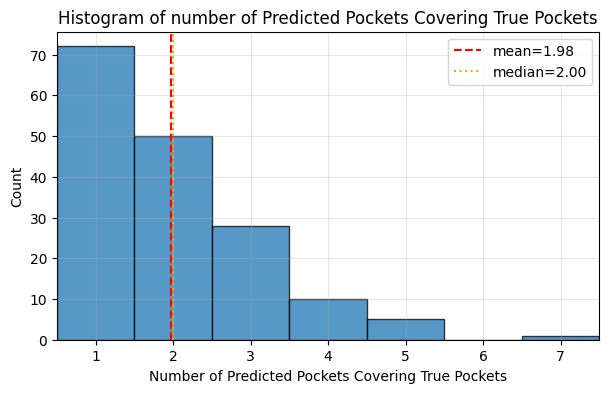

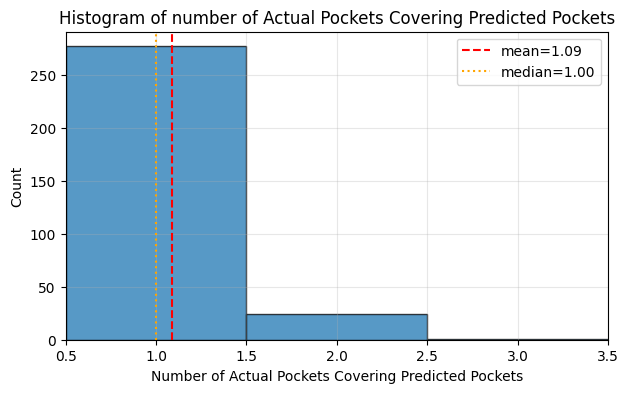

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np

number_of_pockets = sum([len(i) for i in binding_residues.values()])

mean_br = np.mean(best_residue_overlaps)
median_br = np.median(best_residue_overlaps)
print(f'best_residue_overlap mean={mean_br:.4f}, median={median_br:.4f}')

print(np.sum(np.array(DCCs) < 12) / number_of_pockets, f'({np.sum(np.array(DCCs) < 4) / number_of_pockets})')
print(np.sum(np.array(DCCs_N_plus_K) < 12) / number_of_pockets, f'({np.sum(np.array(DCCs_N_plus_K) < 4) / number_of_pockets})')
print(np.sum(np.array(DCCs_N) < 12) / number_of_pockets, f'({np.sum(np.array(DCCs_N) < 4) / number_of_pockets})')


print('\nSmall binding pockets (less than 10 residues):')
small_pockets_DCCs = [DCCs[i] for i in range(len(DCCs)) if is_small_pocket_DCC[i]]
print(f'Overall DCC < 12: {np.sum(np.array(small_pockets_DCCs) < 12) / len(small_pockets_DCCs):.4f} ({np.sum(np.array(small_pockets_DCCs) < 4) / len(small_pockets_DCCs):.4f})')
small_pockets_DCCs_N_plus_K = [DCCs_N_plus_K[i] for i in range(len(DCCs_N_plus_K)) if is_small_pocket_DCC_N_plus_K[i]]
print(f'N+K DCC < 12: {np.sum(np.array(small_pockets_DCCs_N_plus_K) < 12) / len(small_pockets_DCCs_N_plus_K):.4f} ({np.sum(np.array(small_pockets_DCCs_N_plus_K) < 4) / len(small_pockets_DCCs_N_plus_K):.4f})')
small_pockets_DCCs_N = [DCCs_N[i] for i in range(len(DCCs_N)) if is_small_pocket_DCC_N[i]]
print(f'N DCC < 12: {np.sum(np.array(small_pockets_DCCs_N) < 12) / len(small_pockets_DCCs_N):.4f} ({np.sum(np.array(small_pockets_DCCs_N) < 4) / len(small_pockets_DCCs_N):.4f})')

print('\nLarge binding pockets (10 or more residues):')
large_pockets_DCCs = [DCCs[i] for i in range(len(DCCs)) if not is_small_pocket_DCC[i]]
print(f'Overall DCC < 12: {np.sum(np.array(large_pockets_DCCs) < 12) / len(large_pockets_DCCs):.4f} ({np.sum(np.array(large_pockets_DCCs) < 4) / len(large_pockets_DCCs):.4f})')
large_pockets_DCCs_N_plus_K = [DCCs_N_plus_K[i] for i in range(len(DCCs_N_plus_K)) if not is_small_pocket_DCC_N_plus_K[i]]
print(f'N+K DCC < 12: {np.sum(np.array(large_pockets_DCCs_N_plus_K) < 12) / len(large_pockets_DCCs_N_plus_K):.4f} ({np.sum(np.array(large_pockets_DCCs_N_plus_K) < 4) / len(large_pockets_DCCs_N_plus_K):.4f})')
large_pockets_DCCs_N = [DCCs_N[i] for i in range(len(DCCs_N)) if not is_small_pocket_DCC_N[i]]
print(f'N DCC < 12: {np.sum(np.array(large_pockets_DCCs_N) < 12) / len(large_pockets_DCCs_N):.4f} ({np.sum(np.array(large_pockets_DCCs_N) < 4) / len(large_pockets_DCCs_N):.4f})')  


fig, ax = plt.subplots(figsize=(7, 4))

# Remove zeros
number_of_overlapping_actual_sites_on_predicted_pocket_without_zeros = [i for i in number_of_overlapping_actual_sites_on_predicted_pocket if i != 0]
bins = np.arange(-0.5, max(number_of_overlapping_actual_sites_on_predicted_pocket_without_zeros) + 1.5, 1)
ax.clear()
ax.hist(number_of_overlapping_actual_sites_on_predicted_pocket_without_zeros, bins=bins, color='C0', edgecolor='k', alpha=0.75)
mean_cov = np.mean(number_of_overlapping_actual_sites_on_predicted_pocket_without_zeros)
median_cov = np.median(number_of_overlapping_actual_sites_on_predicted_pocket_without_zeros)
ax.axvline(mean_cov, color='red', linestyle='--', label=f"mean={mean_cov:.2f}")
ax.axvline(median_cov, color='orange', linestyle=':', label=f"median={median_cov:.2f}")
ax.set_title("Histogram of number of Predicted Pockets Covering True Pockets")
ax.set_xlim(0.5, max(number_of_overlapping_actual_sites_on_predicted_pocket_without_zeros) + 0.5)
ax.set_xlabel("Number of Predicted Pockets Covering True Pockets")
ax.set_ylabel("Count")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))

# Remove zeros
number_of_overlapping_predictions_on_actual_pocket_without_zeros = [i for i in number_of_overlapping_predictions_on_actual_pocket if i != 0]
bins = np.arange(-0.5, max(number_of_overlapping_predictions_on_actual_pocket_without_zeros) + 1.5, 1)
ax.clear()
ax.hist(number_of_overlapping_predictions_on_actual_pocket_without_zeros, bins=bins, color='C0', edgecolor='k', alpha=0.75)
mean_cov = np.mean(number_of_overlapping_predictions_on_actual_pocket_without_zeros)
median_cov = np.median(number_of_overlapping_predictions_on_actual_pocket_without_zeros)
ax.axvline(mean_cov, color='red', linestyle='--', label=f"mean={mean_cov:.2f}")
ax.axvline(median_cov, color='orange', linestyle=':', label=f"median={median_cov:.2f}")
ax.set_title("Histogram of number of Actual Pockets Covering Predicted Pockets")
ax.set_xlim(0.5, max(number_of_overlapping_predictions_on_actual_pocket_without_zeros) + 0.5)
ax.set_xlabel("Number of Actual Pockets Covering Predicted Pockets")
ax.set_ylabel("Count")
ax.legend()
ax.grid(alpha=0.3)
plt.show()
